In [13]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.retrieval.transformer.preprocess import SequenceGeneratorPandas
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.retrieval.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

# Load Dataset

In [14]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,user_age,user_gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2733,2025-10-21 03:01:00,click,46,Women,Murcia Women Casual Black Handbag,Murcia,1560.0,1560.0,...,Black,Winter,2015,Casual,Accessories,Bags,Handbags,<UNK>,Casual,"<p>Specialising in fashionable style, and craf..."
1,1,2584,2025-10-21 03:02:00,click,46,Women,Murcia Women Zoe Grey Handbags,Murcia,1450.0,1450.0,...,Grey,Winter,2015,Casual,Accessories,Bags,Handbags,<UNK>,Casual,"<p style=""text-align: justify;"">If you want to..."
2,1,1377,2025-10-21 03:05:00,click,46,Women,Murcia Women Casual Black Handbag,Murcia,1650.0,1650.0,...,Black,Winter,2015,Casual,Accessories,Bags,Handbags,<UNK>,Casual,"<p>Specialising in fashionable style, and craf..."
3,1,8241,2025-10-21 03:04:00,click,46,Women,Murcia Women Kkhh Grey Handbags,Murcia,1450.0,1450.0,...,Grey,Winter,2015,Casual,Accessories,Bags,Handbags,<UNK>,Casual,<p>If you want to make a style statement effor...
4,1,1269,2025-10-21 03:17:00,click,46,Women,Lino Perros Women Leatherette Brown Handbag,Lino Perros,2495.0,2495.0,...,Brown,Winter,2015,Casual,Accessories,Bags,Handbags,<UNK>,Casual,<p>You only have one chance to make a good fir...


# Load Model

In [15]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("retrieval_transformer:latest")
reg_model_artifact = bentoml.models.get("retrieval_regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Prediction Test

In [16]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [17]:
sequence_generator = SequenceGeneratorPandas(
    max_seq_len=model.seq_model_config["seq_len"]
)

feature_names = list(model.seq_model_config["feature_sequence_sparse_dims"].keys()) + [
    "item_id"
]

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequence=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample.head()

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
0,1698,1,5,"[0, 0, 0, 0, 0]","[Femella, Femella, Femella, OPIUM, Allen Solly]","[Women, Women, Women, Men, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Blue, Pink, Grey, Gold, Brown]","[Summer, Summer, Summer, Winter, Winter]","[2012, 2012, 2012, 2016, 2016]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Access...","[Scarves, Scarves, Scarves, Eyewear, Eyewear]","[Scarves, Scarves, Scarves, Sunglasses, Sungla...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, wishlist, click]","[1816, 5370, 115, 4059, 9553]","[5370, 115, 4059, 9553, 4270]"
1,1698,2,5,"[0, 0, 0, 0, 0]","[Fastrack, Femella, Femella, Femella, Femella]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[White, White, Blue, Pink, Grey]","[Winter, Summer, Summer, Summer, Summer]","[2016, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Access...","[Watches, Scarves, Scarves, Scarves, Scarves]","[Watches, Scarves, Scarves, Scarves, Scarves]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, click]","[5186, 1329, 1816, 5370, 115]","[1329, 1816, 5370, 115, 4059]"
2,1698,3,5,"[0, 0, 0, 0, 0]","[Femella, Femella, Femella, Femella, OPIUM]","[Women, Women, Women, Women, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[White, Blue, Pink, Grey, Gold]","[Summer, Summer, Summer, Summer, Winter]","[2012, 2012, 2012, 2012, 2016]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Access...","[Scarves, Scarves, Scarves, Scarves, Eyewear]","[Scarves, Scarves, Scarves, Scarves, Sunglasses]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, wishlist]","[1329, 1816, 5370, 115, 4059]","[1816, 5370, 115, 4059, 9553]"
5,1698,6,5,"[0, 0, 0, 0, 0]","[Fastrack, Fastrack, Fastrack, Avirate, Avirate]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[White, Black, Red, Black, Black]","[Winter, Winter, Winter, Fall, Fall]","[2016, 2016, 2016, 2012, 2012]","[Casual, Casual, Casual, Party, Party]","[Accessories, Accessories, Accessories, Appare...","[Watches, Watches, Watches, Dress, Dress]","[Watches, Watches, Watches, Dresses, Dresses]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, Party, Party]","[click, click, click, click, wishlist]","[5186, 3132, 8139, 8434, 2754]","[3132, 8139, 8434, 2754, 6607]"
7,1698,9,5,"[0, 0, 0, 0, 0]","[ESPRIT, Fastrack, Fastrack, Fastrack, Avirate]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[White, White, Black, Red, Black]","[Winter, Winter, Winter, Winter, Fall]","[2016, 2016, 2016, 2016, 2012]","[Casual, Casual, Casual, Casual, Party]","[Accessories, Accessories, Accessories, Access...","[Watches, Watches, Watches, Watches, Dress]","[Watches, Watches, Watches, Watches, Dresses]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, <UNK>, <UNK>, <UNK>, Party]","[click, click, click, click, click]","[9085, 5186, 3132, 8139, 8434]","[5186, 3132, 8139, 8434, 2754]"


In [18]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 1698,
 'user_rn': 2,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Fastrack', 'Femella', 'Femella', 'Femella', 'Femella'],
 'gender': ['Women', 'Women', 'Women', 'Women', 'Women'],
 'age_group': ['Adults-Women',
  'Adults-Women',
  'Adults-Women',
  'Adults-Women',
  'Adults-Women'],
 'base_color': ['White', 'White', 'Blue', 'Pink', 'Grey'],
 'season': ['Winter', 'Summer', 'Summer', 'Summer', 'Summer'],
 'year': ['2016', '2012', '2012', '2012', '2012'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Accessories',
  'Accessories',
  'Accessories',
  'Accessories',
  'Accessories'],
 'sub_category': ['Watches', 'Scarves', 'Scarves', 'Scarves', 'Scarves'],
 'article_type': ['Watches', 'Scarves', 'Scarves', 'Scarves', 'Scarves'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'action': ['click', 'click', 'click', 'click', 'click'],
 'item_id': [5186, 1329, 1816,

In [19]:
inputs = {}
for k in model.seq_model_config["feature_sequence_sparse_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['click', 'click', 'click', 'click', 'click'],
 'age_group': ['Adults-Women',
               'Adults-Women',
               'Adults-Women',
               'Adults-Women',
               'Adults-Women'],
 'article_type': ['Watches', 'Scarves', 'Scarves', 'Scarves', 'Scarves'],
 'base_color': ['White', 'White', 'Blue', 'Pink', 'Grey'],
 'brand_name': ['Fastrack', 'Femella', 'Femella', 'Femella', 'Femella'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Women', 'Women', 'Women', 'Women', 'Women'],
 'master_category': ['Accessories',
                     'Accessories',
                     'Accessories',
                     'Accessories',
                     'Accessories'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'season': ['Winter', 'Summer', 'Summer', 'Summer', 'Summer'],
 'sub_category': ['Watches', 'Scarves', 'Scarves', 'Scarves', 'Scarves'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'year': ['2016', '2012', '

In [20]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": {"feature_sequence_sparse": inputs}}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

{'feature_sequence_sparse': {'brand_name': ['Fastrack', 'Femella', 'Femella', 'Femella', 'Femella'], 'gender': ['Women', 'Women', 'Women', 'Women', 'Women'], 'age_group': ['Adults-Women', 'Adults-Women', 'Adults-Women', 'Adults-Women', 'Adults-Women'], 'base_color': ['White', 'White', 'Blue', 'Pink', 'Grey'], 'season': ['Winter', 'Summer', 'Summer', 'Summer', 'Summer'], 'year': ['2016', '2012', '2012', '2012', '2012'], 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'], 'master_category': ['Accessories', 'Accessories', 'Accessories', 'Accessories', 'Accessories'], 'sub_category': ['Watches', 'Scarves', 'Scarves', 'Scarves', 'Scarves'], 'article_type': ['Watches', 'Scarves', 'Scarves', 'Scarves', 'Scarves'], 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'], 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'], 'action': ['click', 'click', 'click', 'click', 'click']}}


# Recommendation

In [21]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [22]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [23]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{6843: 0.9045054912567139,
 9490: 0.9029282331466675,
 9198: 0.9027727246284485,
 9799: 0.9017006754875183,
 9931: 0.9016788601875305,
 9925: 0.9016360640525818,
 2226: 0.9015465378761292,
 4081: 0.9014787077903748,
 9721: 0.9007424712181091,
 2406: 0.9005839228630066,
 5018: 0.9004877209663391,
 4127: 0.8998647332191467,
 320: 0.8997231125831604,
 7308: 0.8990628719329834,
 1321: 0.8986610174179077,
 7991: 0.8980286121368408,
 3618: 0.8977870941162109,
 8614: 0.8976576328277588,
 5928: 0.8975471258163452,
 8507: 0.8975021839141846,
 1747: 0.8974217176437378,
 3468: 0.8964945673942566,
 9348: 0.8963994979858398,
 2283: 0.8963910937309265,
 3086: 0.8963603973388672,
 4852: 0.8963457942008972,
 9975: 0.8956143260002136,
 8974: 0.8956050276756287,
 63: 0.8955773711204529,
 2066: 0.8951915502548218}

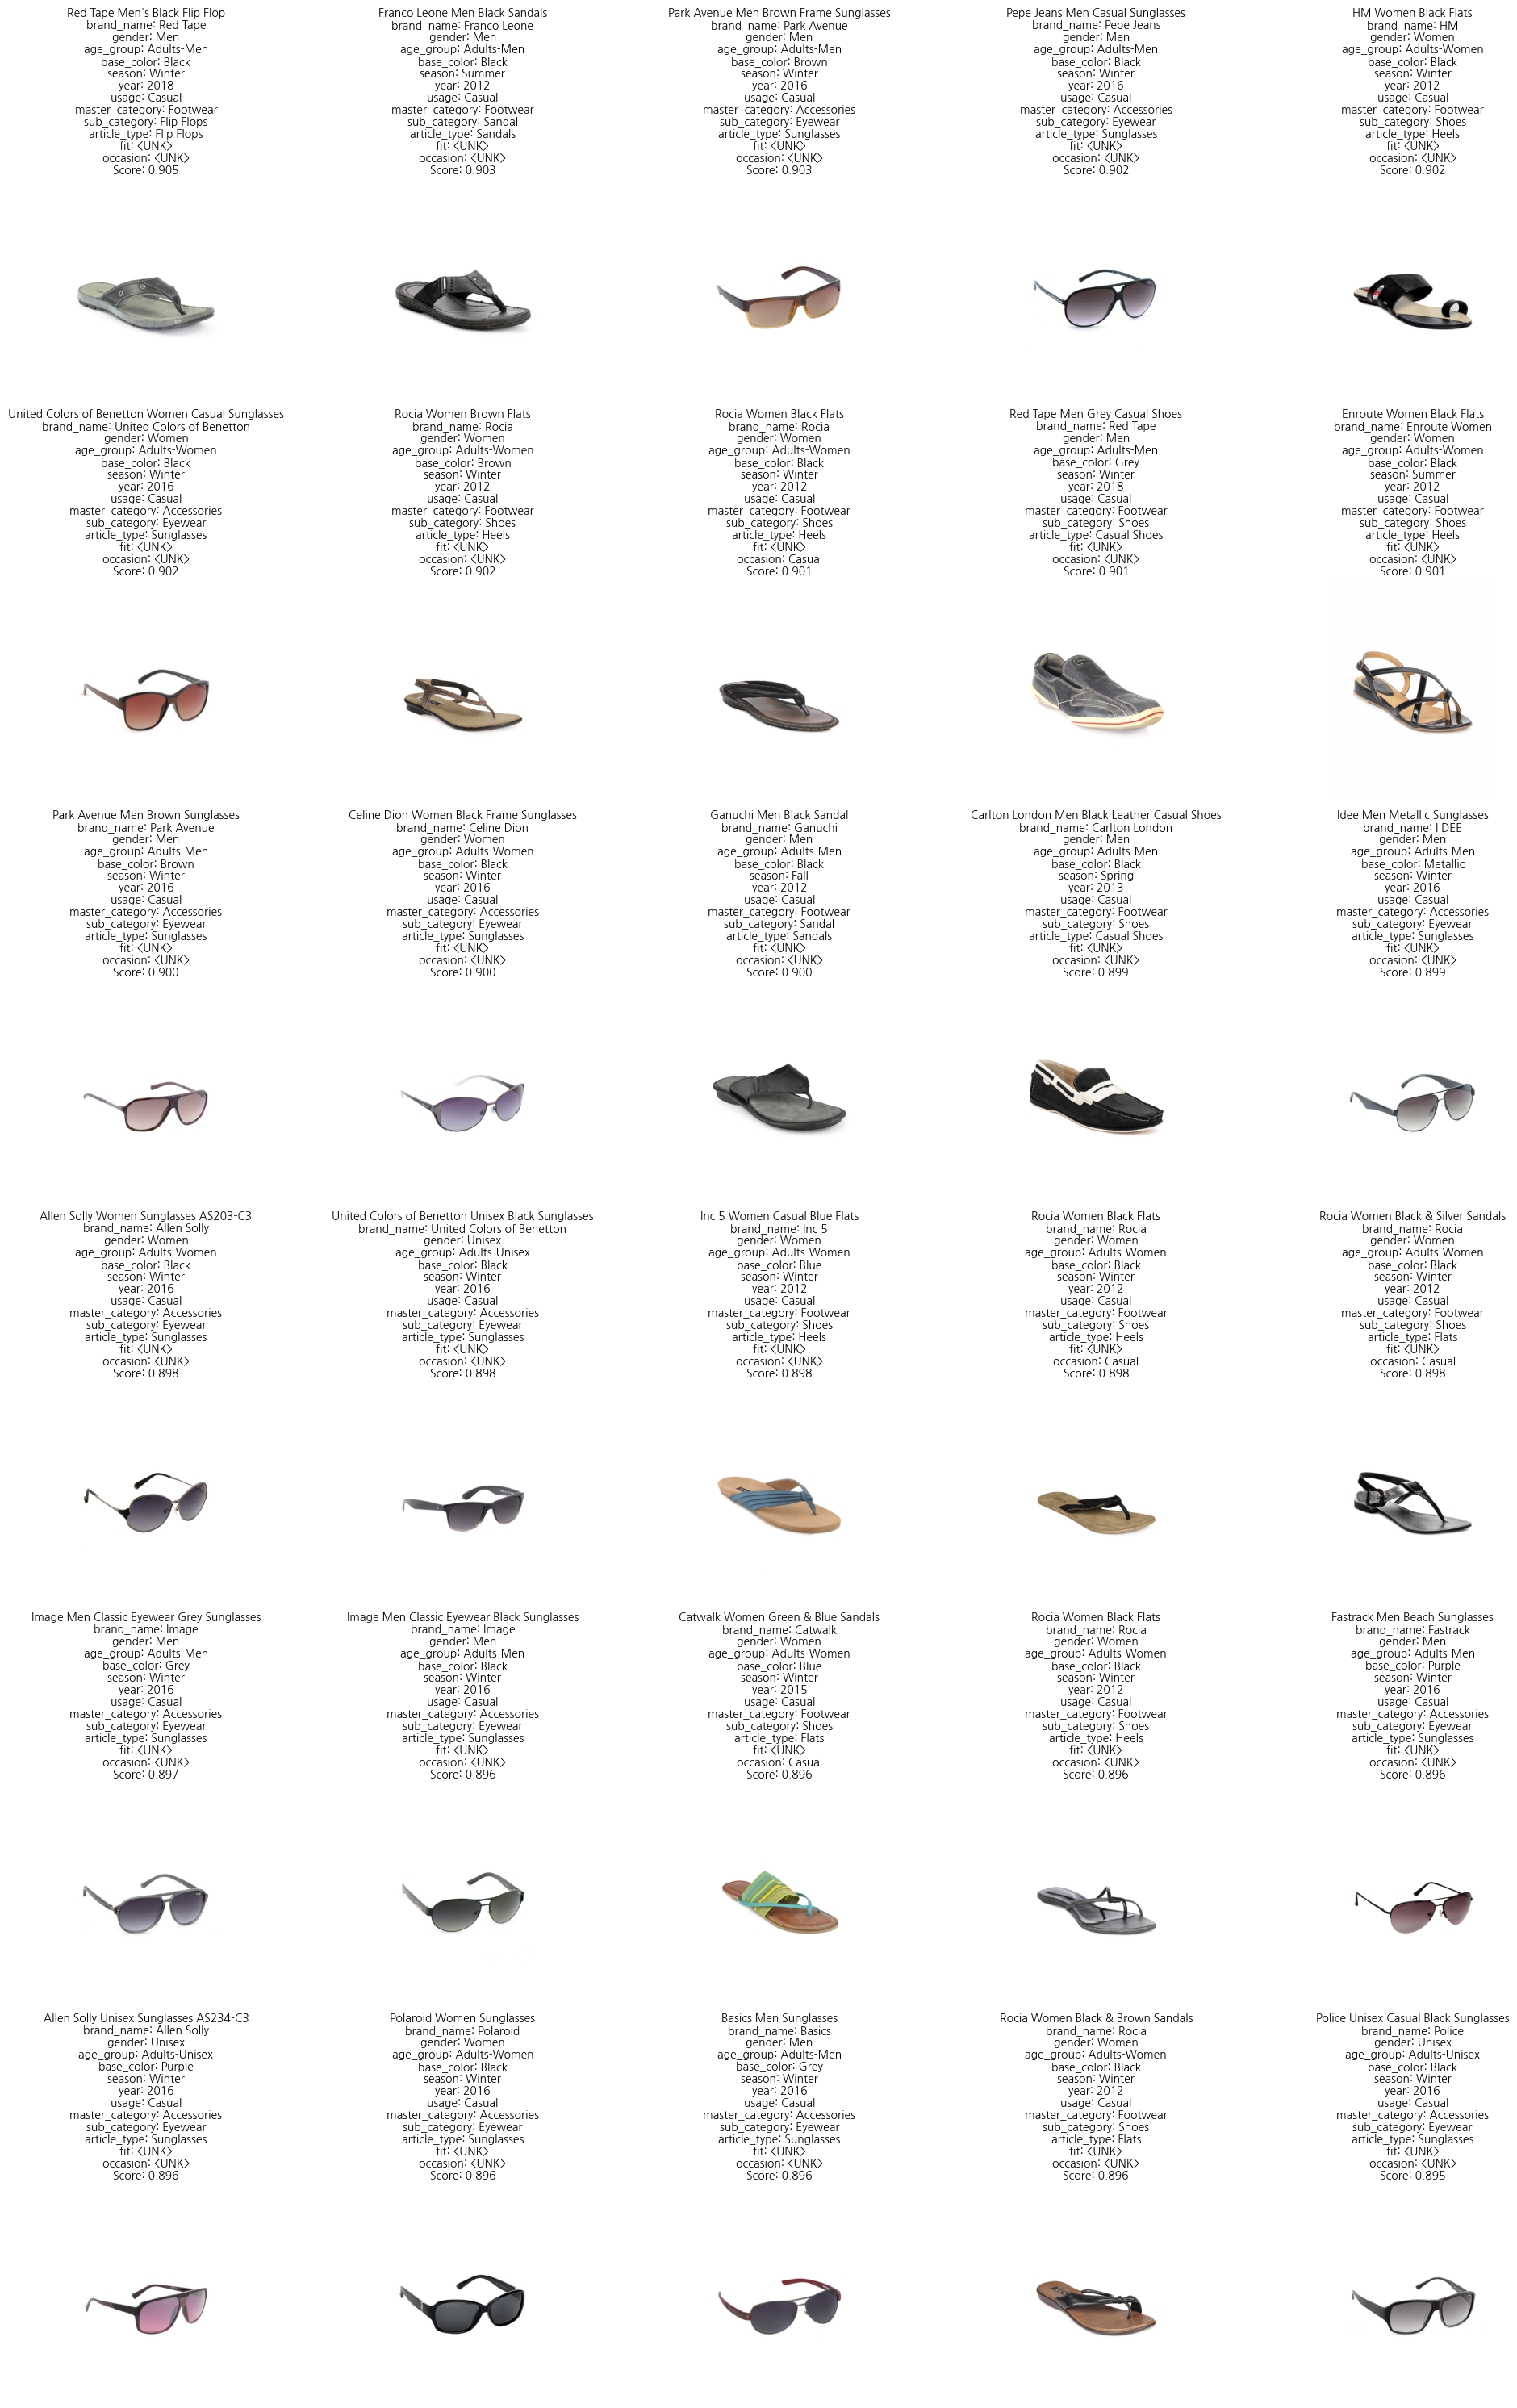

In [24]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_sequence_sparse_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.dataset_dir.joinpath("images"),
)